# Minimal Full-Pipeline Soliton Demo

This notebook runs the same workflow as `main.py`: build `q(x,0)`, compute continuous and discrete scattering data, evolve the scattering data, and reconstruct `q(x,t)` with the GLM equation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from main import run_soliton_pipeline

In [5]:
result = run_soliton_pipeline(
    n_x=256,
    length=4.0,
    eta=4.0,
    xi=0.1,
    x0=0.0,
    phi=0.0,
    t=4.0,
    n_scatter=256,
    chebyshev_nodes=256,
    marchenko_size=16,
    spectrum_solver="parallel",
    marchenko_solver="quantum",
    n_jobs=-1,
    show_progress=False,
)
print("lambda_j:", result["boundStates"])
print(f"relative L2 error: {result['relative_l2_error']:.3e}")

lambda_j: [-0.09999892+3.99985426j]
relative L2 error: 7.189e-02


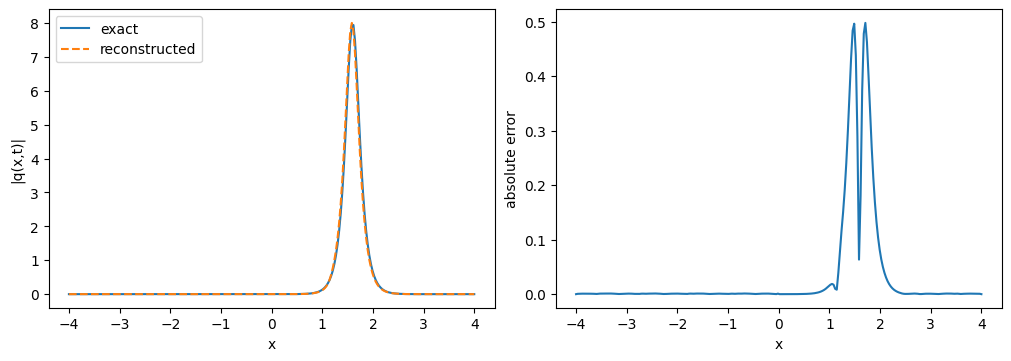

In [7]:
x = result["x"]
reconstructed = result["reconstructed"]
exact = result["exact"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(x, np.abs(exact), label="exact")
axes[0].plot(x, np.abs(reconstructed), "--", label="reconstructed")
axes[0].set_xlabel("x")
axes[0].set_ylabel("|q(x,t)|")
axes[0].legend()

axes[1].plot(x, np.abs(np.abs(reconstructed) - np.abs(exact)))
axes[1].set_xlabel("x")
axes[1].set_ylabel("absolute error")
plt.show()